In [66]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

#import weightedcalcs as wc
#import numpy as np

import pyarrow as pa
import pyarrow.parquet as pq

In [67]:
country_list = pd.read_csv("C:\\github\\median-tariff\\data\\country-list-20.csv", header=None, names=["CTY_CODE"])

figfile = "C:\\github\\how-restrictive-us-trade\\figures\\"

In [68]:
def make_tariff_country_date(dfcntry, date):
   
   bar = dfcntry[(dfcntry['time'] == date)].copy()

   bar["tariff"] = bar["CAL_DUT_MO"] / bar["CON_VAL_MO"]

   bar = bar[["I_COMMODITY", "CON_VAL_MO", "CAL_DUT_MO", "tariff", "CTY_NAME"]]

   return bar

In [69]:
def make_good_country_year(dfcntry, year):
    """
    Process country data for a specific year and calculate aggregate metrics.
    
    Parameters:
    -----------
    dfcntry : pandas.DataFrame
        DataFrame containing country trade data with columns:
        - time: datetime
        - I_COMMODITY: commodity code
        - CON_VAL_MO: consumption value
        - CAL_DUT_MO: calculated duty
        - CTY_NAME: country name
    year : str
        Year to filter data (e.g., "2024")
    
    Returns:
    --------
    pandas.DataFrame
        Aggregated data by commodity for the specified year
    """
    # Filter to specific year
    df_year = dfcntry[dfcntry['time']== year]
    
    # Group by commodity and aggregate
    grp = df_year.groupby("I_COMMODITY")
    
    result = grp.agg({
        "CON_VAL_MO": "sum",
        "CAL_DUT_MO": "sum",
        "CTY_NAME": "first"})
    
    
    return result

In [70]:
country_list.head()

,CTY_CODE
0,5700
1,2010
2,1220
3,5880
4,4280


In [71]:
def process_countries_for_date(country_list, target_date, weight_year="2024", selected_country=None):
    """
    Process multiple countries and create combined dataset with weights.
    
    Parameters:
    -----------
    country_list : pandas.DataFrame or list
        DataFrame with CTY_CODE column or list of country codes
    target_date : str
        Date to extract tariff data for (e.g., "2025-08")
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    selected_country : str, optional
        Country name to filter results (e.g., "CANADA"). If None, returns all countries (default: None)
    
    Returns:
    --------
    pandas.DataFrame
        Combined dataframe with tariff data and weights for all countries (or selected country)
    """
    # Handle both DataFrame and list inputs
    if isinstance(country_list, pd.DataFrame):
        countries = country_list.CTY_CODE
    else:
        countries = country_list
    
    all_results = []
    tariff_results = []
    
    for country in countries:
        
        file = f"C:\\github\\median-tariff\\data\\imports-hs10\\{country}data-current.parquet"
        
        # Load country data
        dfcntry = pq.read_table(file).to_pandas()
        
        dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

        dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

        dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

        dfcntry["applied_tariff"] = dfcntry["CAL_DUT_MO"] / dfcntry["CON_VAL_MO"]
            
        # Calculate metrics for weight year
        results_df = make_good_country_year(dfcntry, weight_year)

        results_df.reset_index(inplace=True)
        
        # Get tariff data for target date
        tariff_df = make_tariff_country_date(dfcntry, target_date)

        tariff_df.reset_index(drop=True, inplace=True)
        
        # Add to lists
        all_results.append(results_df)

        tariff_results.append(tariff_df)
        
        #print(f"Processed {country}: {results_df['CTY_NAME'].iloc[0]}")
    
    # Combine all results into one dataframe
    combined_results = pd.concat(all_results)
    combined_results.reset_index(drop=True, inplace=True)
    
    combined_tariff_results = pd.concat(tariff_results)
    combined_tariff_results.reset_index(drop=True, inplace=True)
    
    # Calculate weights
    combined_results["weights"] = combined_results["CON_VAL_MO"] / combined_results["CON_VAL_MO"].sum()
    
    # Merge weights with tariff data
    bigdf = pd.merge(
        combined_results[["I_COMMODITY", "CTY_NAME", "weights"]], 
        combined_tariff_results, 
        how="left", 
        on=["I_COMMODITY", "CTY_NAME"]
    )
    
    # Filter to selected country if specified
    if selected_country is not None:
        bigdf = bigdf[bigdf["CTY_NAME"] == selected_country].copy()
        # Renormalize weights to sum to 1 for the selected country
        bigdf["weights"] = bigdf["weights"] / bigdf["weights"].sum()
    
    return bigdf

In [72]:
def create_tariff_metrics_by_date_country(country_list, date_list, weight_year="2024"):
    """
    Calculate tariff metrics for multiple dates and countries.
    
    Parameters:
    -----------
    country_list : pandas.DataFrame or list
        DataFrame with CTY_CODE column or list of country codes
    date_list : list
        List of date strings to process (e.g., ["2024-08", "2025-02", "2025-08"])
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with columns: date, CTY_NAME, sqrtariff, meanweighted, simplemean
    """
    results = []
    
    for date in date_list:
        print(f"Processing date: {date}")
        
        # Get data for this date (all countries)
        bigdf = process_countries_for_date(country_list, date, weight_year=weight_year)
        
        # Calculate metrics for ALL COUNTRIES combined
        sqrtariff_all = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5
        meanweighted_all = (bigdf["tariff"] * bigdf["weights"]).sum()
        simplemean_all = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()
        
        # Store ALL COUNTRIES results
        results.append({
            'date': date,
            'CTY_NAME': 'ALL COUNTRIES',
            'sqrtariff': sqrtariff_all,
            'meanweighted': meanweighted_all,
            'simplemean': simplemean_all
        })
        
        # Get unique countries in this dataset
        countries = bigdf['CTY_NAME'].unique()
        
        for country in countries:
            # Filter to this country
            country_df = bigdf[bigdf['CTY_NAME'] == country].copy()
            
            # Renormalize weights to sum to 1 for this country
            country_df["weights"] = country_df["weights"] / country_df["weights"].sum()
            
            # Calculate metrics
            sqrtariff = ((country_df["tariff"]**2 * country_df["weights"]).sum())**0.5
            meanweighted = (country_df["tariff"] * country_df["weights"]).sum()
            simplemean = country_df['CAL_DUT_MO'].sum() / country_df["CON_VAL_MO"].sum()
            
            # Store results
            results.append({
                'date': date,
                'CTY_NAME': country,
                'sqrtariff': sqrtariff,
                'meanweighted': meanweighted,
                'simplemean': simplemean
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

In [76]:
bigdf = process_countries_for_date(country_list, "2025-09", weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted RMS Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

Weighted RMS Tariff: 23.22%
 
Weighted Mean Tariff: 14.57%
 
Simple Mean Tariff: 10.78%


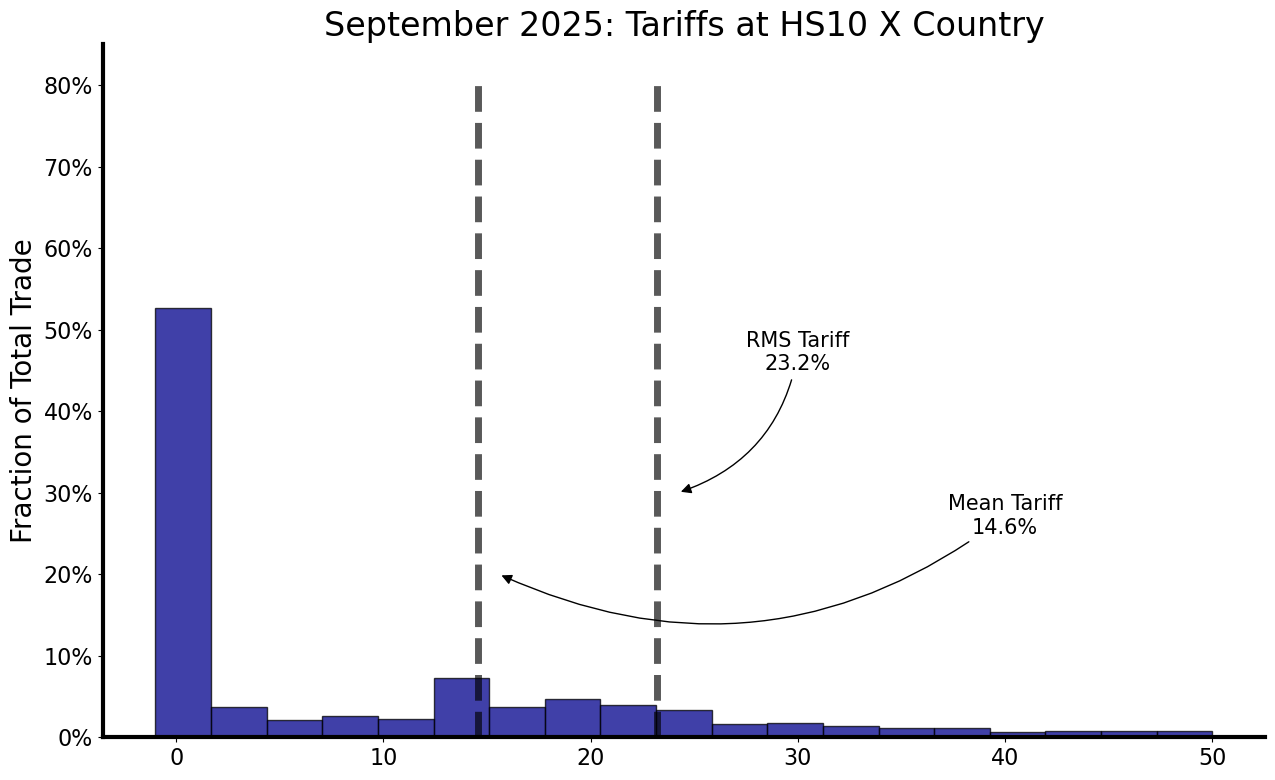

In [77]:
fig, ax = plt.subplots(figsize = (15,9))

# fig = plt.figure(figsize=(15, 9))
# bax_ax = bax.brokenaxes(ylims=((0, 0.20), (0.40, 0.50)), hspace=.05)

bin_edges = np.linspace(-1, 50, 20)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(100*bigdf["tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = bigdf.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / bigdf["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkblue', alpha=0.75, edgecolor='black')

# ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("September 2025: Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.vlines(100*sqrtariff, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("RMS Tariff\n{:.1f}%".format(100*sqrtariff), 
            xy=(100*sqrtariff+1, 0.3), 
            xytext=(30, 0.45),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*meanweighted, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Mean Tariff\n{:.1f}%".format(100*meanweighted), 
            xy=(100*meanweighted+1, 0.20), 
            xytext=(40, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.85)

# plt.savefig(figfile+"aug2025-histogram.png", bbox_inches = "tight")

# plt.savefig(figfile+"aug2025-histogram.pdf", bbox_inches = "tight")

plt.show()

In [78]:
bigdf = process_countries_for_date(country_list, "2024-09", weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted RMS Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

Weighted RMS Tariff: 7.23%
 
Weighted Mean Tariff: 2.69%
 
Simple Mean Tariff: 2.56%


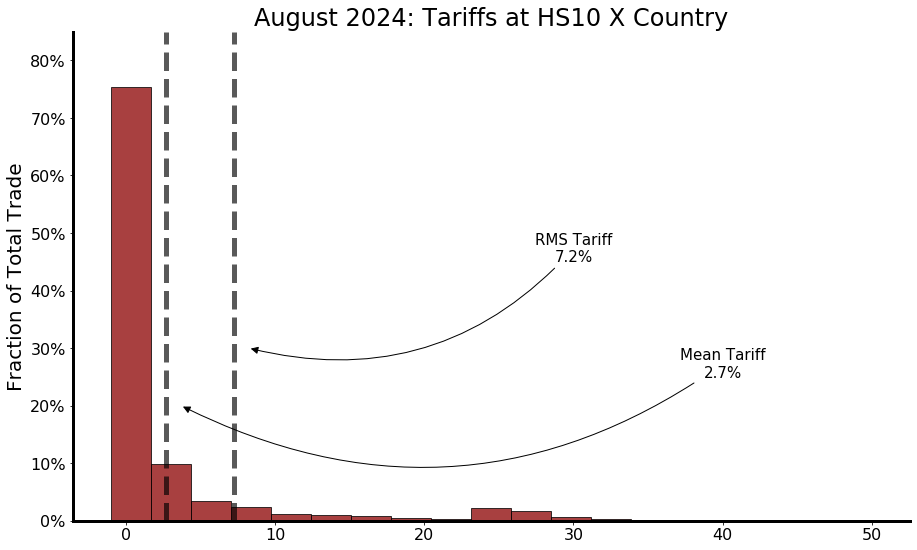

In [ ]:
fig, ax = plt.subplots(figsize = (15,9))

# fig = plt.figure(figsize=(15, 9))
# bax_ax = bax.brokenaxes(ylims=((0, 0.20), (0.40, 0.50)), hspace=.05)

bin_edges = np.linspace(-1, 50, 20)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(100*bigdf["tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = bigdf.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / bigdf["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkred', alpha=0.75, edgecolor='black')



ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

ax.set_title("August 2024: Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

# mediantariff = foo["applied_tariff"].median()

ax.vlines(100*sqrtariff, 0, 0.85, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("RMS Tariff\n{:.1f}%".format(100*sqrtariff), 
            xy=(100*sqrtariff+1, 0.3), 
            xytext=(30, 0.45),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*meanweighted, 0, 0.85, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Mean Tariff\n{:.1f}%".format(100*meanweighted), 
            xy=(100*meanweighted+1, 0.20), 
            xytext=(40, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.85)

plt.savefig(figfile+"aug2024-histogram.png", bbox_inches = "tight")

plt.savefig(figfile+"aug2024-histogram.pdf", bbox_inches = "tight")

plt.show()

In [ ]:
bigdf = process_countries_for_date(country_list, "2025-02", weight_year="2024", selected_country="CHINA")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted RMS Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

Weighted RMS Tariff: 17.93%
 
Weighted Mean Tariff: 13.75%
 
Simple Mean Tariff: 12.83%


In [79]:
date_list = ["2025-01", "2025-02", "2025-03", "2025-04", "2025-05", "2025-06", "2025-07", "2025-08", "2025-09"]

metrics_df = create_tariff_metrics_by_date_country(country_list, date_list, weight_year="2024")

metrics_df["date"] = pd.to_datetime(metrics_df["date"], format="%Y-%m")

Processing date: 2025-01
Processing date: 2025-02
Processing date: 2025-03
Processing date: 2025-04
Processing date: 2025-05
Processing date: 2025-06
Processing date: 2025-07
Processing date: 2025-08
Processing date: 2025-09


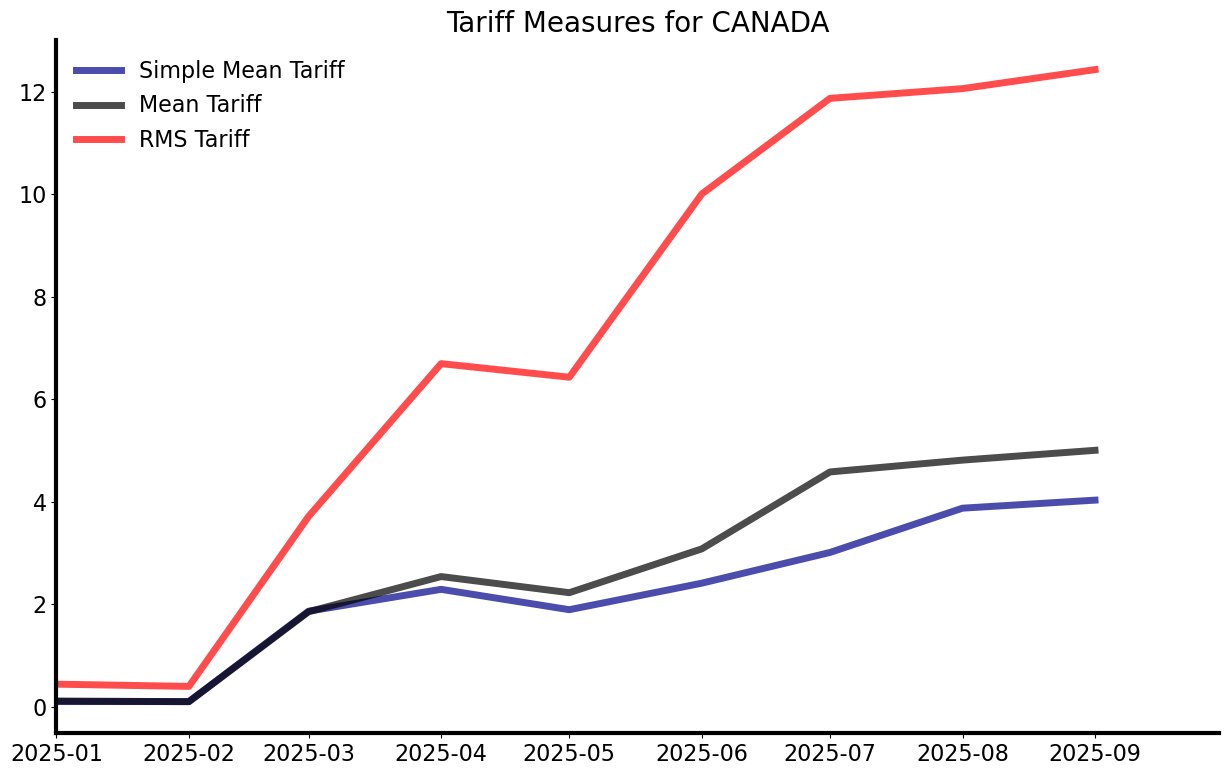

In [81]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "CANADA"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "RMS Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

ax.set_ylim(top=13)

# plt.savefig(figfile+"canada-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"canada-tariffs.pdf", bbox_inches = "tight")

plt.show()

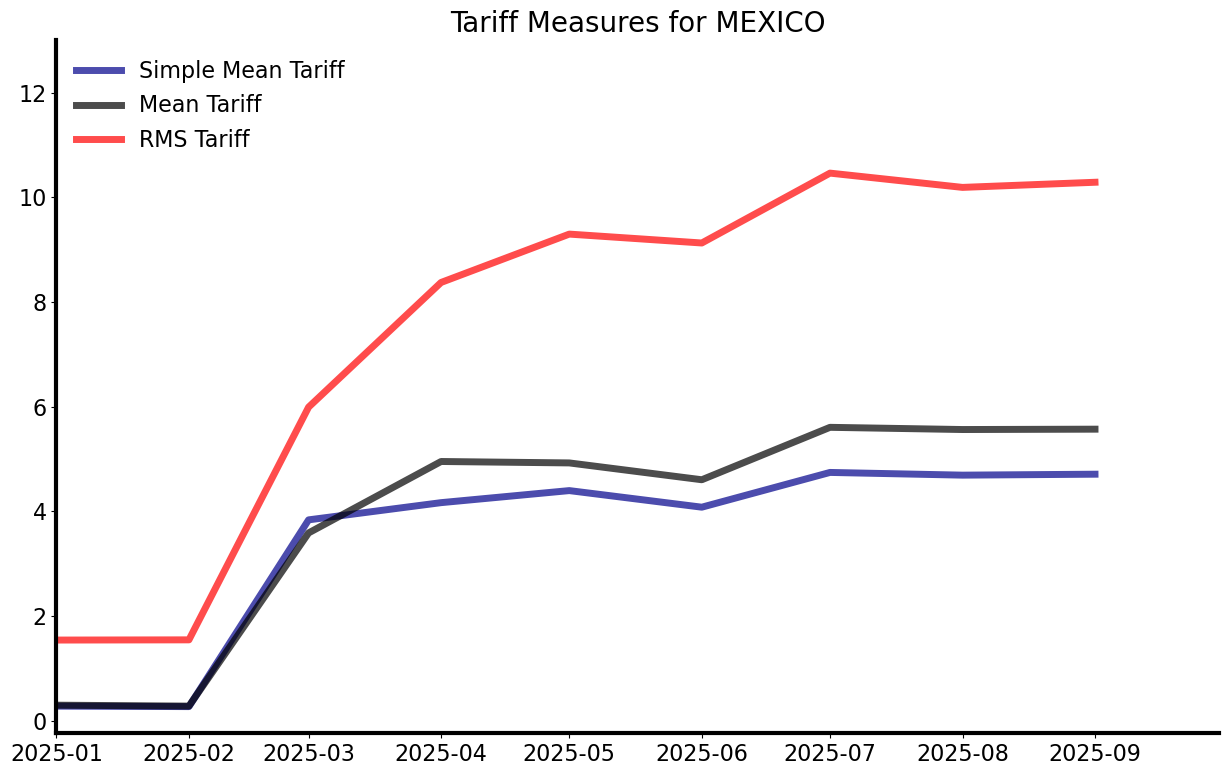

In [82]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "MEXICO"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "RMS Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

ax.set_ylim(top=13)

# plt.savefig(figfile+"mexico-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"mexico-tariffs.pdf", bbox_inches = "tight")

plt.show()

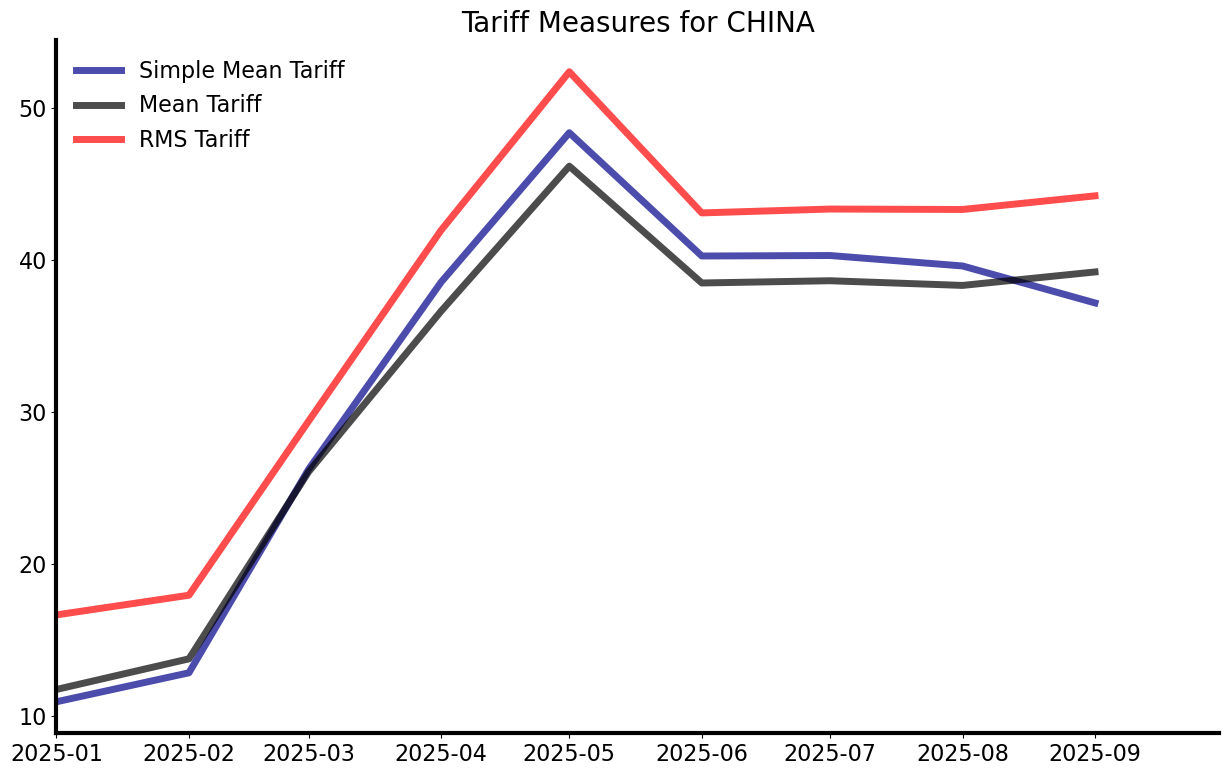

In [83]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "CHINA"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "RMS Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

# plt.savefig(figfile+"china-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"china-tariffs.pdf", bbox_inches = "tight")

plt.show()

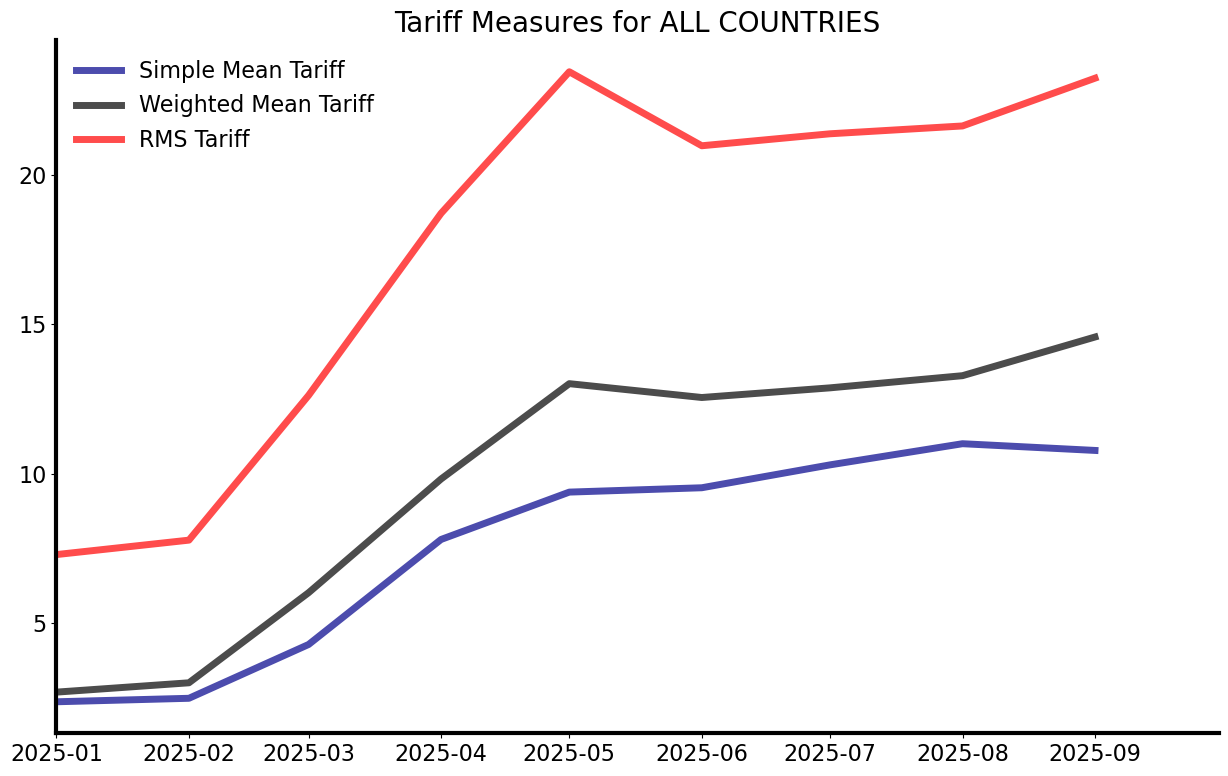

In [84]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "ALL COUNTRIES"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Weighted Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "RMS Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

# plt.savefig(figfile+"all-countries-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"all-countries-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [ ]:
metrics_df.head(10)

,date,CTY_NAME,sqrtariff,meanweighted,simplemean
0,2025-01-01,ALL COUNTRIES,0.072983,0.026995,0.023769
1,2025-01-01,CHINA,0.166387,0.117357,0.109256
2,2025-01-01,MEXICO,0.015409,0.002967,0.002783
3,2025-01-01,CANADA,0.004428,0.001146,0.001039
4,2025-01-01,JAPAN,0.023599,0.014937,0.015602
5,2025-01-01,GERMANY,0.022285,0.012023,0.011518
6,2025-01-01,"KOREA, SOUTH",0.008892,0.001976,0.002400
7,2025-01-01,VIETNAM,0.086862,0.041732,0.035865
8,2025-01-01,TAIWAN,0.029600,0.010429,0.009254
9,2025-01-01,IRELAND,0.022416,0.005367,0.001078


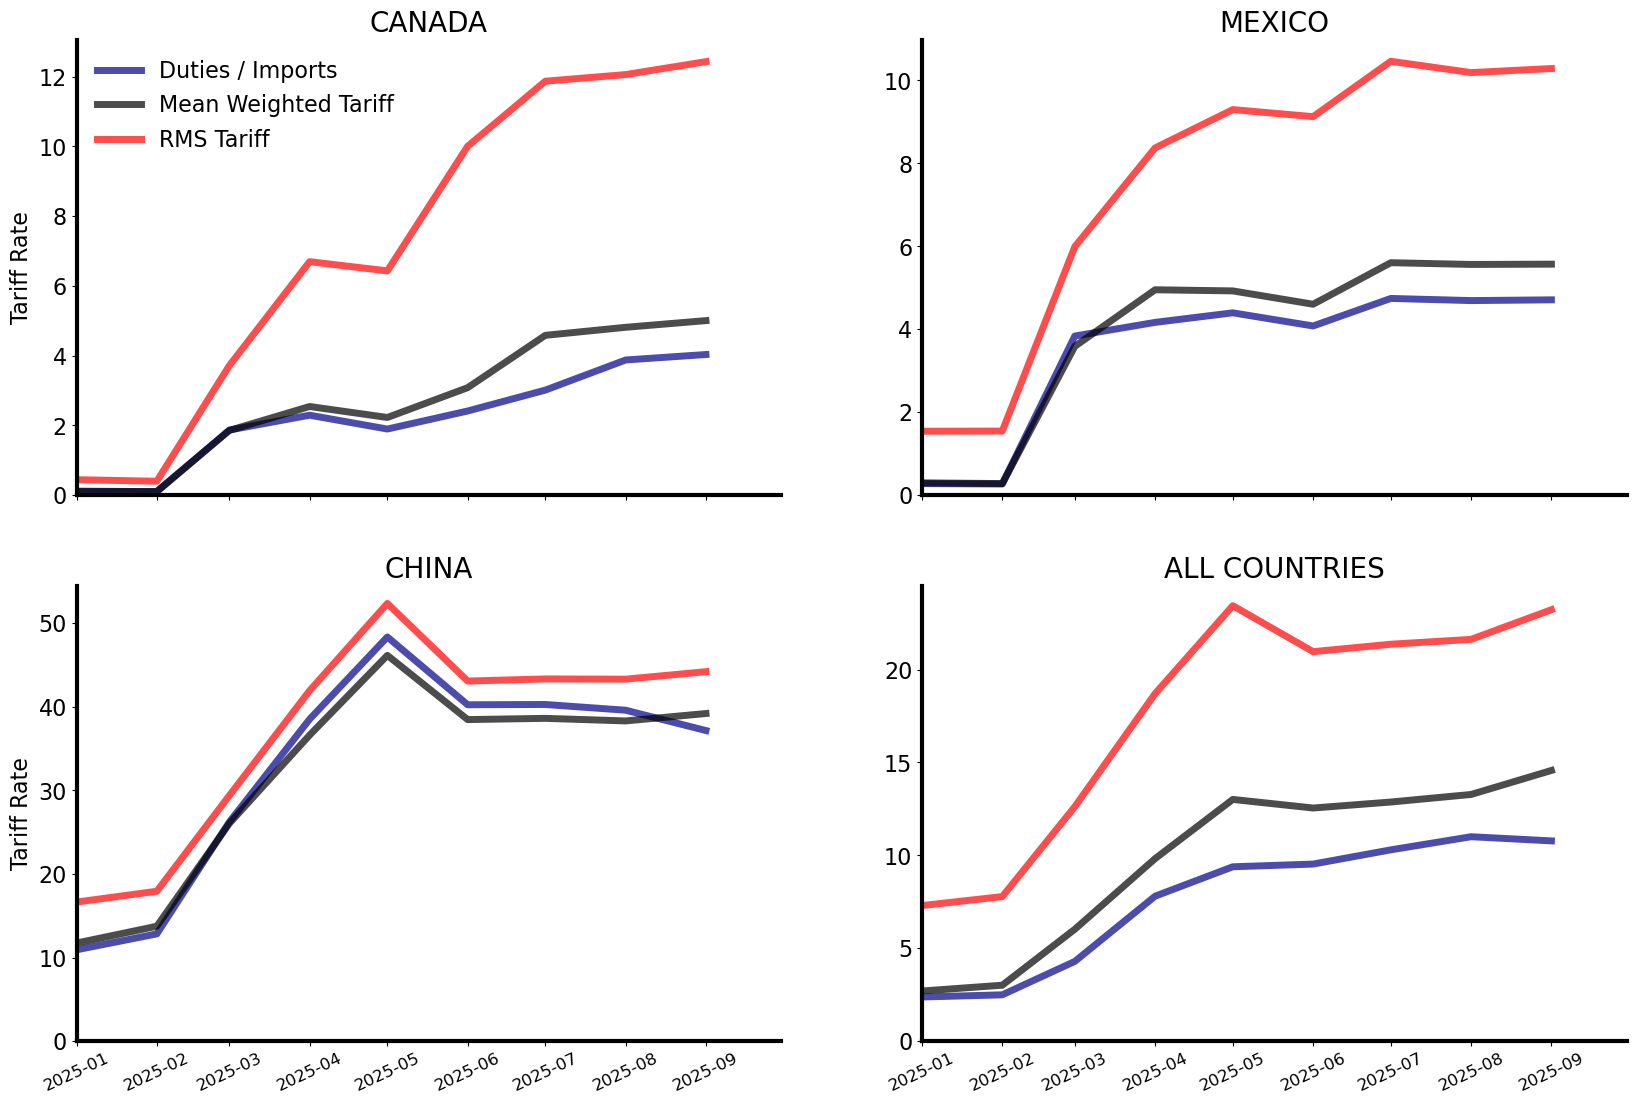

In [86]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, sharex = True, figsize = (20,13)) 

countries = ["CANADA", "MEXICO", "CHINA", "ALL COUNTRIES"]

ax = ax.ravel() # Here is the trick here, ax is a 2 by 2 array. We want to work through it in a loop...so
                # one way to do this is to flatten stuff out, make it a 4 by 1 array. The ravel command 
                # does this...
    
for i, (ax, country) in enumerate(zip(ax, countries)):

    foo = metrics_df[metrics_df["CTY_NAME"] == country].copy()

    ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Duties / Imports")

    ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Weighted Tariff")

    ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "RMS Tariff")

    ax.set_title( foo["CTY_NAME"].iloc[0], fontsize = 20)

    ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,9,30)])

    ax.set_ylim(bottom=0)

    ax.tick_params(axis='x', labelsize=12, rotation=25)
    ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

    ax.spines["right"].set_visible(False)

    ax.spines["top"].set_visible(False)

    ax.spines["left"].set_linewidth(3)

    ax.spines["bottom"].set_linewidth(3)

    if i == 0:  # Only show legend in first plot
        ax.legend(
            fontsize=16,           # Font size
            frameon=False,         # No box
            loc='upper left',     # Position
            ncol=1                 # Number of columns
        )

        ax.set_ylabel("Tariff Rate", fontsize=16)

    if i == 2:

        ax.set_ylabel("Tariff Rate", fontsize=16)


# plt.savefig(figfile+"panel-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"panel-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [ ]:
foobar = process_countries_for_date(country_list, "2025-08", weight_year="2024", selected_country="MEXICO")

In [ ]:
foobar["tariff"] = 100*foobar["tariff"]

In [ ]:
foobar.sort_values(by="weights", ascending=False).iloc[0:50]

,I_COMMODITY,CTY_NAME,weights,CON_VAL_MO,CAL_DUT_MO,tariff
15800,8471500150,MEXICO,0.059115,7.749918e+09,6054924.0,0.078129
16658,8703230140,MEXICO,0.051010,1.708001e+09,375619086.0,21.991743
16682,8704310140,MEXICO,0.032978,1.258668e+09,191169877.0,15.188265
16672,8704210100,MEXICO,0.024789,1.049757e+08,8101825.0,7.717809
16592,8544300000,MEXICO,0.022103,1.021305e+09,18151745.0,1.777309
16656,8703220110,MEXICO,0.021876,1.132702e+09,126266540.0,11.147378
16645,8701210015,MEXICO,0.018261,3.233672e+08,39540.0,0.012228
16711,8708295160,MEXICO,0.016368,6.501807e+08,56955284.0,8.759916
16349,8528726460,MEXICO,0.012958,7.612324e+08,75543.0,0.009924
11912,2709002090,MEXICO,0.012189,2.338305e+08,0.0,0.000000


In [ ]:
metrics_df[metrics_df["CTY_NAME"] == "ALL COUNTRIES"]

,date,CTY_NAME,sqrtariff,meanweighted,simplemean
0,2025-01-01,ALL COUNTRIES,0.072983,0.026995,0.023769
21,2025-02-01,ALL COUNTRIES,0.077809,0.030116,0.024934
42,2025-03-01,ALL COUNTRIES,0.126215,0.060242,0.042925
63,2025-04-01,ALL COUNTRIES,0.187079,0.098257,0.078039
84,2025-05-01,ALL COUNTRIES,0.234395,0.130121,0.093868
105,2025-06-01,ALL COUNTRIES,0.209661,0.125494,0.095321
126,2025-07-01,ALL COUNTRIES,0.213664,0.128722,0.102974
147,2025-08-01,ALL COUNTRIES,0.216281,0.132792,0.110047


In [ ]:
metrics_df_2025 = create_tariff_metrics_by_date_country(country_list, ["2025-08"], weight_year="2024")

metrics_df_2024 = create_tariff_metrics_by_date_country(country_list, ["2024-08"], weight_year="2024")

Processing date: 2025-08
Processing date: 2024-08
Processing date: 2024-08


In [ ]:
metrics_df_2024.head()


,date,CTY_NAME,sqrtariff,meanweighted,simplemean
0,2024-08,ALL COUNTRIES,0.072424,0.027086,0.027002
1,2024-08,CHINA,0.164109,0.116642,0.110614
2,2024-08,MEXICO,0.015180,0.002463,0.002600
3,2024-08,CANADA,0.003856,0.000848,0.000922
4,2024-08,JAPAN,0.024211,0.015064,0.015817


In [ ]:
metrics_df_2025.head()

,date,CTY_NAME,sqrtariff,meanweighted,simplemean
0,2025-08,ALL COUNTRIES,0.216281,0.132792,0.110047
1,2025-08,CHINA,0.433054,0.383106,0.395907
2,2025-08,MEXICO,0.101892,0.055632,0.046916
3,2025-08,CANADA,0.120570,0.048121,0.038750
4,2025-08,JAPAN,0.203172,0.170014,0.172581


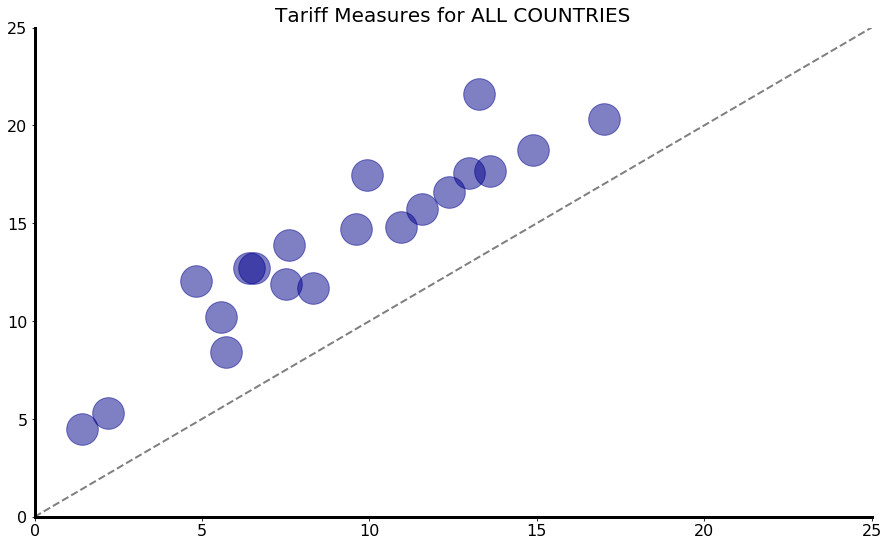

In [ ]:
fig, ax = plt.subplots(figsize = (15,9))

ax.scatter( metrics_df_2025.meanweighted*100, metrics_df_2025.sqrtariff*100, color = "darkblue", alpha = 0.5, s=1000)

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

# ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,8,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.set_xlim(0, 25)
ax.set_ylim(0, 25)

# Add 45-degree line
ax.plot([0, 45], [0, 45], 'k--', linewidth=2, alpha=0.5, label='45° line')

# ax.legend(
#     fontsize=16,           # Font size
#     frameon=False,         # No box
#     loc='upper left',     # Position
#     ncol=1                 # Number of columns
# )

# plt.savefig(figfile+"all-countries-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"all-countries-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [ ]:
metrics_df_2025.sort_values(by="sqrtariff", ascending=False).iloc[0:21]

,date,CTY_NAME,sqrtariff,meanweighted,simplemean
1,2025-08,CHINA,0.433054,0.383106,0.395907
0,2025-08,ALL COUNTRIES,0.216281,0.132792,0.110047
4,2025-08,JAPAN,0.203172,0.170014,0.172581
6,2025-08,"KOREA, SOUTH",0.187467,0.148852,0.142935
20,2025-08,INDONESIA,0.176852,0.135973,0.148162
7,2025-08,VIETNAM,0.175869,0.129630,0.098863
17,2025-08,BRAZIL,0.174471,0.099272,0.116574
5,2025-08,GERMANY,0.166187,0.123676,0.134283
16,2025-08,THAILAND,0.157433,0.115765,0.080380
12,2025-08,ITALY,0.148232,0.109469,0.109227


In [ ]:
# Create mapping dictionary for ISO3 codes
country_to_iso3 = {
    'CANADA': 'CAN',
    'MEXICO': 'MEX',
    'CHINA': 'CHN',
    'JAPAN': 'JPN',
    'GERMANY': 'DEU',
    'KOREA, SOUTH': 'KOR',
    'UNITED KINGDOM': 'GBR',
    'FRANCE': 'FRA',
    'INDIA': 'IND',
    'ITALY': 'ITA',
    'TAIWAN': 'TWN',
    'VIETNAM': 'VNM',
    'IRELAND': 'IRL',
    'SWITZERLAND': 'CHE',
    'THAILAND': 'THA',
    'NETHERLANDS': 'NLD',
    'BRAZIL': 'BRA',
    'BELGIUM': 'BEL',
    'SINGAPORE': 'SGP',
    'INDONESIA': 'IDN',
    'ALL COUNTRIES': 'WLD'  # World aggregate
}

# Add ISO3 codes to dataframes
metrics_df_2025['ISO3'] = metrics_df_2025['CTY_NAME'].map(country_to_iso3)
# metrics_df_2024['ISO3'] = metrics_df_2024['CTY_NAME'].map(country_to_iso3)
# metrics_df['ISO3'] = metrics_df['CTY_NAME'].map(country_to_iso3)

In [ ]:
metrics_df_2025.head(20)

,date,CTY_NAME,sqrtariff,meanweighted,simplemean,ISO3
0,2025-08,ALL COUNTRIES,0.216281,0.132792,0.110047,WLD
1,2025-08,CHINA,0.433054,0.383106,0.395907,CHN
2,2025-08,MEXICO,0.101892,0.055632,0.046916,MEX
3,2025-08,CANADA,0.120570,0.048121,0.038750,CAN
4,2025-08,JAPAN,0.203172,0.170014,0.172581,JPN
5,2025-08,GERMANY,0.166187,0.123676,0.134283,DEU
6,2025-08,"KOREA, SOUTH",0.187467,0.148852,0.142935,KOR
7,2025-08,VIETNAM,0.175869,0.129630,0.098863,VNM
8,2025-08,TAIWAN,0.138661,0.075878,0.035901,TWN
9,2025-08,IRELAND,0.044849,0.014169,0.015994,IRL


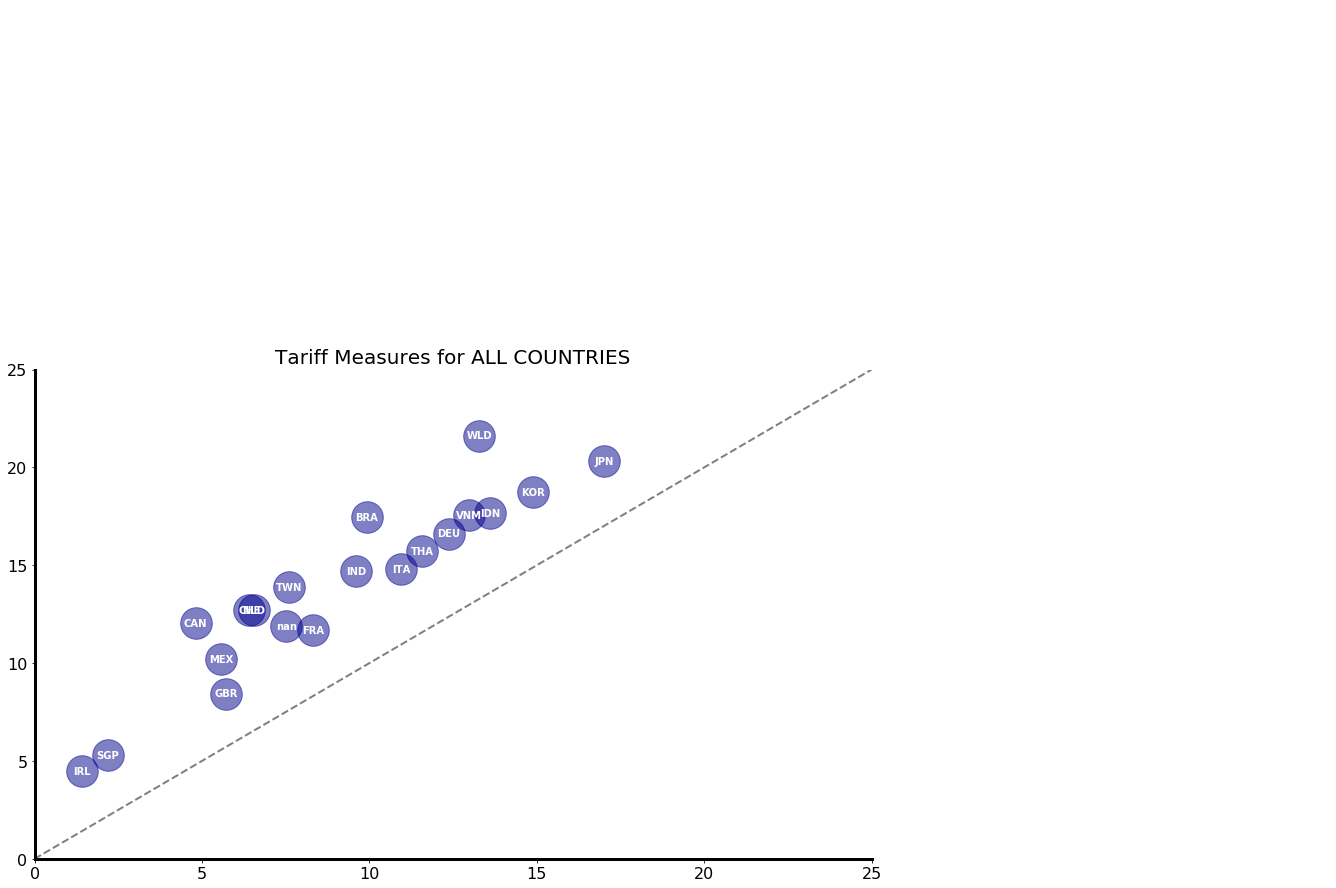

In [ ]:
fig, ax = plt.subplots(figsize = (15,9))

ax.scatter( metrics_df_2025.meanweighted*100, metrics_df_2025.sqrtariff*100, color = "darkblue", alpha = 0.5, s=1000)

# Add ISO3 labels to each point
for idx, row in metrics_df_2025.iterrows():
    ax.text(row['meanweighted']*100, row['sqrtariff']*100, row['ISO3'], 
            fontsize=10, ha='center', va='center', color='white', fontweight='bold')

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

# ax.set_xlim([dt.datetime(2025,1,1), dt.datetime(2025,8,30)])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.set_xlim(0, 25)
ax.set_ylim(0, 25)

# Add 45-degree line
ax.plot([0, 45], [0, 45], 'k--', linewidth=2, alpha=0.5, label='45° line')

# ax.legend(
#     fontsize=16,           # Font size
#     frameon=False,         # No box
#     loc='upper left',     # Position
#     ncol=1                 # Number of columns
# )

# plt.savefig(figfile+"all-countries-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"all-countries-tariffs.pdf", bbox_inches = "tight")

plt.show()
